# 🏊 AquaGuard AI — Notebook 1: Pool Segmentation
**BUS61104 · Taylor's University · Group 20 · April 2026**

---

### Objective
Train and compare three YOLOv8-seg variants to segment the **pool water surface polygon**.
The best model becomes Stage 1 of the live detection pipeline — it defines the zone
where child detection and drowning detection are allowed to run.

### Dataset
**Pool Localisation** — `ehsangooyahotmailcom-6xaas/pool-localisation`  
603 images · 1 class (`pool`) · Instance segmentation masks · mAP50 93.3% (pre-validated)

### Models compared
| # | Variant | Speed | Expected mAP |
|---|---|---|---|
| 1 | YOLOv8n-seg | Fastest | ~88–91% |
| 2 | YOLOv8s-seg | Medium ⭐ | ~91–94% |
| 3 | YOLOv8m-seg | Slower | ~93–96% |

---


## 1 · Setup

In [5]:
# 1.1 Install required packages
!pip install ultralytics roboflow opencv-python matplotlib seaborn pandas -q
print('✓ Packages installed')

✓ Packages installed


In [6]:
# 1.2 Imports
import os, json, cv2, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime
from ultralytics import YOLO
from roboflow import Roboflow
import yaml

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('✓ Imports ready')

✓ Imports ready


In [7]:
# 1.3 Mount Google Drive — all outputs save here
from google.colab import drive
drive.mount('/content/drive')

# ── Directory structure ──────────────────────────────────────────
DRIVE       = Path('/content/drive/MyDrive/AquaGuard_AI')
SAVE_DIR    = DRIVE / 'results' / 'model1_pool_seg'
EDA_DIR     = SAVE_DIR / 'eda'
TRAIN_DIR   = SAVE_DIR / 'training'
CMP_DIR     = SAVE_DIR / 'comparison'

for d in [EDA_DIR, TRAIN_DIR, CMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'✓ Save directory: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Save directory: /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg


---
## 2 · Dataset

Loading directly via the Roboflow API — no manual download needed.


In [8]:
# 2.1 Load dataset via Roboflow API
API_KEY = 'wyyShOQCMCVEyCXpQzPs'  # ← paste your key here

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace('ehsangooyahotmailcom-6xaas').project('pool-localisation')
dataset = project.version(1).download('yolov8')

DATA_YAML = Path(dataset.location) / 'data.yaml'
DATA_ROOT = Path(dataset.location)

print(f'✓ Dataset downloaded to: {DATA_ROOT}')
print(f'✓ data.yaml: {DATA_YAML}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pool-localisation-1 in yolov8:: 100%|██████████| 2906/2906 [00:00<00:00, 17813.15it/s]

✓ Dataset downloaded to: /content/pool-localisation-1
✓ data.yaml: /content/pool-localisation-1/data.yaml


In [9]:
# 2.2 Inspect data.yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print('data.yaml contents:')
for k, v in cfg.items():
    print(f'  {k}: {v}')

data.yaml contents:
  names: ['pool']
  nc: 1
  roboflow: {'license': 'CC BY 4.0', 'project': 'pool-localisation', 'url': 'https://universe.roboflow.com/ehsangooyahotmailcom-6xaas/pool-localisation/dataset/1', 'version': 1, 'workspace': 'ehsangooyahotmailcom-6xaas'}
  test: ../test/images
  train: ../train/images
  val: ../valid/images


---
## 3 · Exploratory Data Analysis


In [10]:
# 3.1 Dataset split statistics
split_stats = {}
for split in ['train', 'valid', 'test']:
    img_dir = DATA_ROOT / split / 'images'
    lbl_dir = DATA_ROOT / split / 'labels'
    if img_dir.exists():
        imgs  = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
        lbls  = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
        split_stats[split] = {'images': len(imgs), 'labels': len(lbls)}

total = sum(v['images'] for v in split_stats.values())

print('─' * 40)
print(f'  Dataset: Pool Localisation')
print(f'  Class:   pool (1 class)')
print('─' * 40)
for split, stats in split_stats.items():
    pct = stats['images'] / total * 100
    print(f'  {split:<8}: {stats["images"]:>4} images  ({pct:.0f}%)')
print(f'  {"TOTAL":<8}: {total:>4} images')
print('─' * 40)

────────────────────────────────────────
  Dataset: Pool Localisation
  Class:   pool (1 class)
────────────────────────────────────────
  train   : 1266 images  (87%)
  valid   :  121 images  (8%)
  test    :   60 images  (4%)
  TOTAL   : 1447 images
────────────────────────────────────────


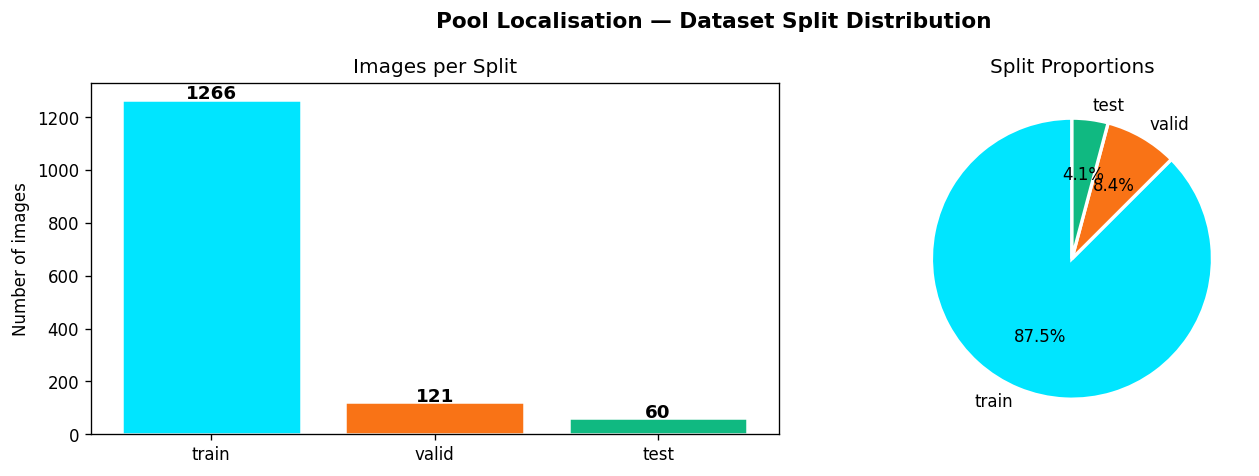

✓ Saved → eda/dataset_split.png


In [11]:
# 3.2 Split distribution chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Pool Localisation — Dataset Split Distribution', fontsize=13, fontweight='bold')

splits = list(split_stats.keys())
counts = [split_stats[s]['images'] for s in splits]
colors = ['#00E5FF', '#F97316', '#10B981']

# Bar chart
bars = axes[0].bar(splits, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Number of images')
axes[0].set_title('Images per Split')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 3,
                 str(val), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=splits, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Split Proportions')

plt.tight_layout()
plt.savefig(str(EDA_DIR / 'dataset_split.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Saved → eda/dataset_split.png')

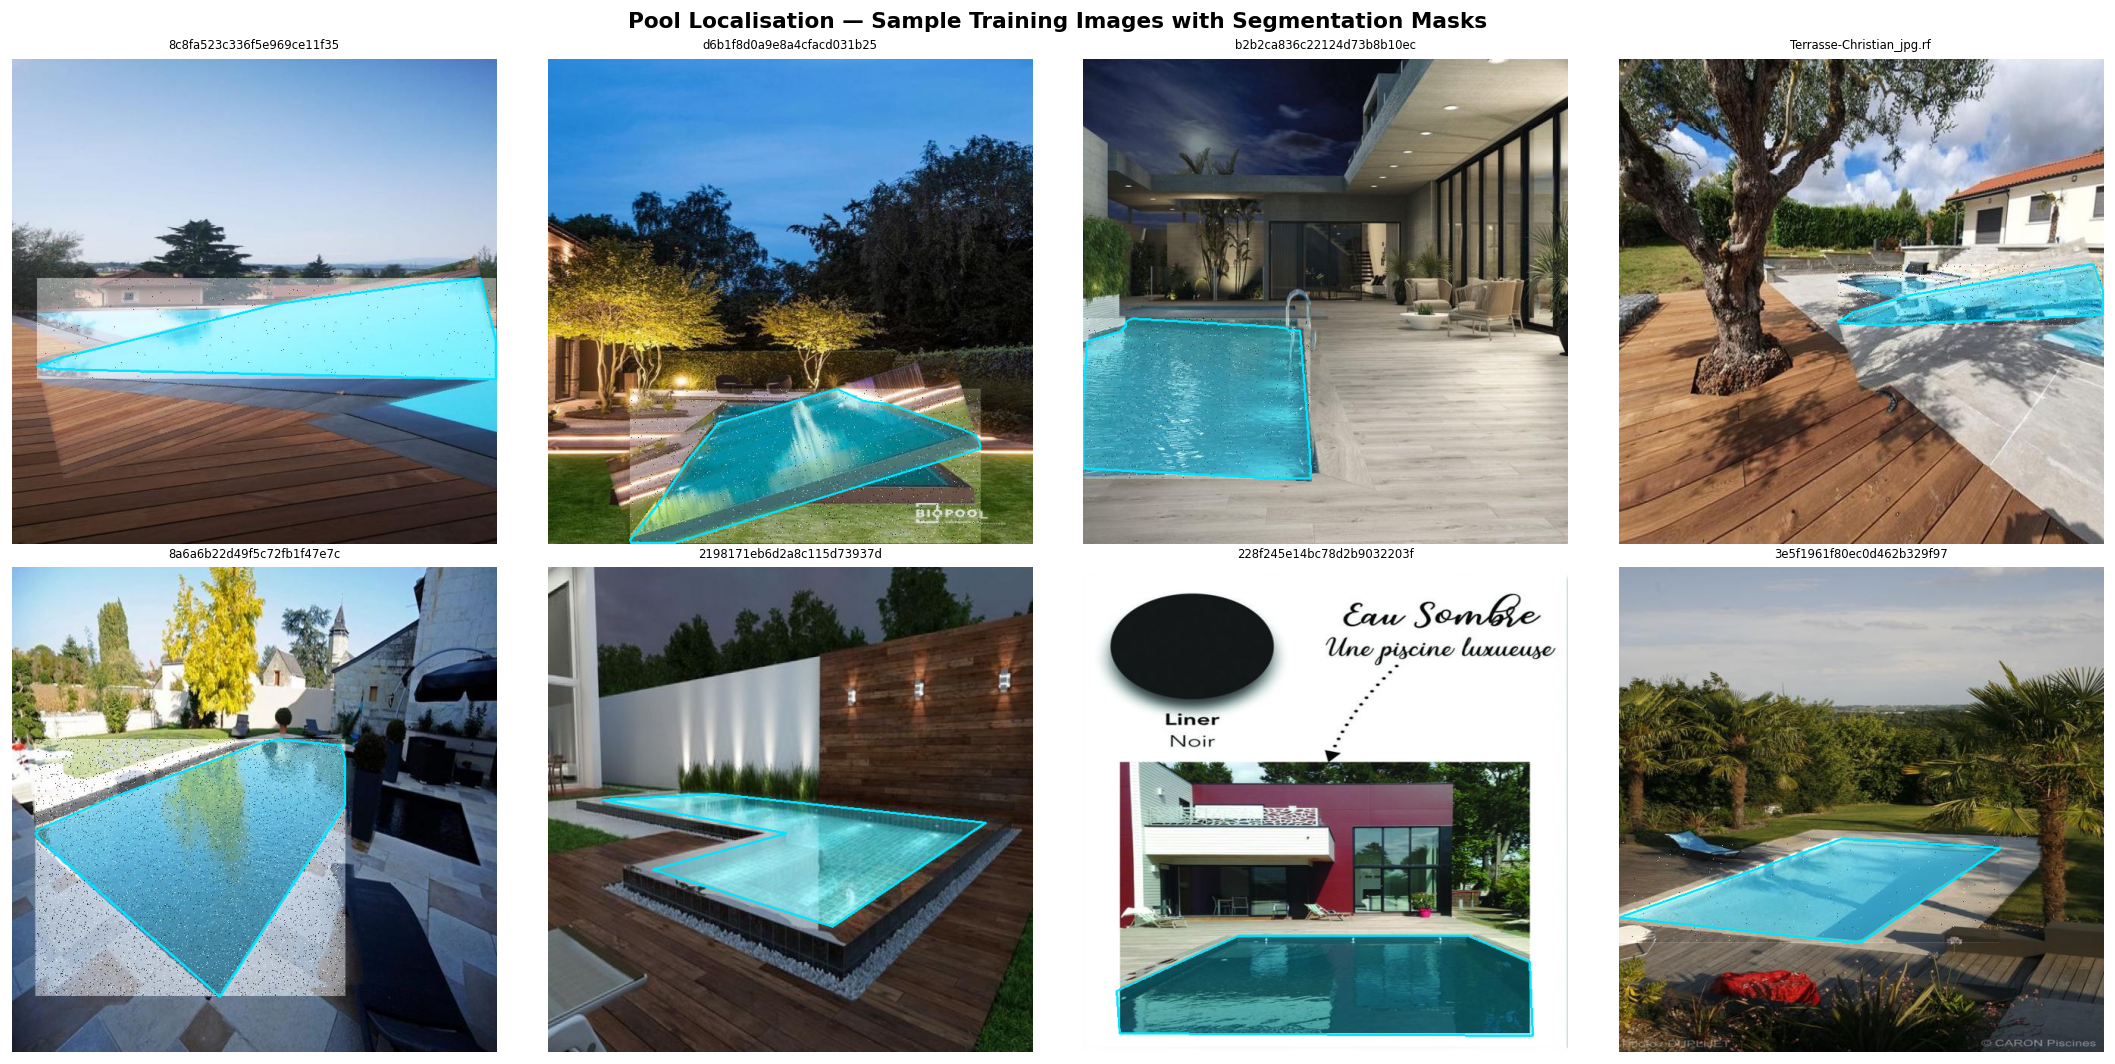

✓ Saved → eda/sample_images.png


In [12]:
# 3.3 Sample images with segmentation masks (8 samples)
train_imgs = list((DATA_ROOT / 'train' / 'images').glob('*.jpg'))
train_imgs += list((DATA_ROOT / 'train' / 'images').glob('*.png'))
samples = random.sample(train_imgs, min(8, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Pool Localisation — Sample Training Images with Segmentation Masks',
             fontsize=13, fontweight='bold')

for ax, img_path in zip(axes.flatten(), samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Load and draw segmentation polygon
    lbl_path = str(img_path).replace('/images/', '/labels/')
    lbl_path = lbl_path.replace('.jpg', '.txt').replace('.png', '.txt')

    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            parts = list(map(float, line.strip().split()))
            if len(parts) > 1:
                pts = np.array(parts[1:]).reshape(-1, 2)
                pts[:, 0] *= w; pts[:, 1] *= h
                pts = pts.astype(np.int32)
                # Fill with semi-transparent teal
                overlay = img.copy()
                cv2.fillPoly(overlay, [pts], (0, 229, 255))
                img = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)
                # Draw border
                cv2.polylines(img, [pts], True, (0, 229, 255), 2)

    ax.imshow(img)
    ax.set_title(Path(img_path).name[:25], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig(str(EDA_DIR / 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✓ Saved → eda/sample_images.png')

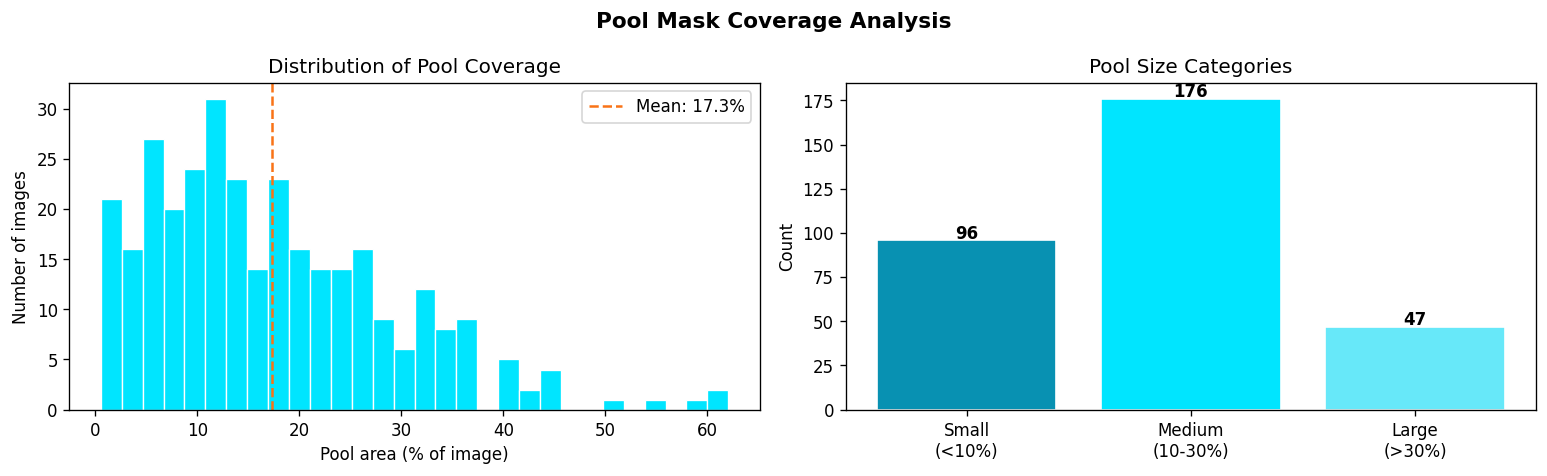

✓ Saved → eda/mask_coverage.png
  Coverage → Mean: 17.3%  Median: 14.5%


In [13]:
# 3.4 Pool mask coverage analysis — what % of each image is pool
coverages = []
lbl_dir   = DATA_ROOT / 'train' / 'labels'

for lf in list(lbl_dir.glob('*.txt'))[:300]:  # sample 300 for speed
    for line in open(lf):
        parts = list(map(float, line.strip().split()))
        if len(parts) > 1:
            # Approximate coverage using bounding box of polygon
            pts  = np.array(parts[1:]).reshape(-1, 2)
            area = 0.5 * abs(sum(
                pts[i][0]*pts[(i+1)%len(pts)][1] - pts[(i+1)%len(pts)][0]*pts[i][1]
                for i in range(len(pts))
            ))
            coverages.append(area * 100)  # as % of image

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Pool Mask Coverage Analysis', fontsize=13, fontweight='bold')

axes[0].hist(coverages, bins=30, color='#00E5FF', edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Pool area (% of image)')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Distribution of Pool Coverage')
axes[0].axvline(np.mean(coverages), color='#F97316', linestyle='--',
                label=f'Mean: {np.mean(coverages):.1f}%')
axes[0].legend()

# Box plot by coverage range
ranges = ['Small\n(<10%)', 'Medium\n(10-30%)', 'Large\n(>30%)']
range_counts = [
    sum(1 for c in coverages if c < 10),
    sum(1 for c in coverages if 10 <= c <= 30),
    sum(1 for c in coverages if c > 30),
]
axes[1].bar(ranges, range_counts,
            color=['#0891B2', '#00E5FF', '#67E8F9'], edgecolor='white')
axes[1].set_ylabel('Count'); axes[1].set_title('Pool Size Categories')
for i, v in enumerate(range_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(EDA_DIR / 'mask_coverage.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Saved → eda/mask_coverage.png')
print(f'  Coverage → Mean: {np.mean(coverages):.1f}%  Median: {np.median(coverages):.1f}%')

In [14]:
# 3.5 Save EDA summary
eda_summary = {
    'dataset'        : 'pool-localisation',
    'workspace'      : 'ehsangooyahotmailcom-6xaas',
    'total_images'   : total,
    'splits'         : split_stats,
    'classes'        : cfg.get('names', ['pool']),
    'coverage_mean'  : round(float(np.mean(coverages)), 2),
    'coverage_median': round(float(np.median(coverages)), 2),
    'generated_at'   : datetime.now().isoformat(),
}
json.dump(eda_summary, open(str(EDA_DIR / 'dataset_stats.json'), 'w'), indent=2)
print('✓ Saved → eda/dataset_stats.json')
print('\n✓ EDA complete — 4 files saved to Google Drive')

✓ Saved → eda/dataset_stats.json

✓ EDA complete — 4 files saved to Google Drive


---
## 4 · Model Training

Training strategy for 603 images:
- **Full fine-tuning** from COCO pre-trained weights (`freeze=0`)
- 603 images is sufficient for the backbone to adapt to pool shapes
- Heavy augmentation to maximise dataset diversity
- `patience=15` stops training early if no improvement


In [15]:
# 4.0 Common training configuration
COMMON = dict(
    data     = str(DATA_YAML),
    epochs   = 50,
    imgsz    = 640,
    batch    = 8,
    patience = 15,
    freeze   = 0,         # full fine-tune — 603 images is enough
    lr0      = 0.01,
    lrf      = 0.01,
    augment  = True,
    fliplr   = 0.5,       # horizontal flip
    degrees  = 15,        # rotation — pools at different angles
    hsv_v    = 0.4,       # brightness — pool lighting changes
    hsv_s    = 0.3,       # saturation — water colour variation
    scale    = 0.5,       # scale — pool at different zoom levels
    plots    = True,      # save training curves automatically
    verbose  = False,
    project  = str(TRAIN_DIR),
)
print('✓ Training config ready')

✓ Training config ready


### 4.1 · YOLOv8n-seg — Nano (baseline)

In [16]:
model_n = YOLO('yolov8n-seg.pt')
print('Training YOLOv8n-seg...')
t0 = time.time()
model_n.train(**COMMON, name='yolov8n_seg')
val_n = model_n.val()
t_n   = round(time.time() - t0, 1)

print(f'\nYOLOv8n-seg results:')
print(f'  mAP50 (mask):  {val_n.seg.map50:.4f}')
print(f'  mAP50 (box):   {val_n.box.map50:.4f}')
print(f'  Inference:     {val_n.speed["inference"]:.1f} ms')
print(f'  Training time: {t_n}s')

Training YOLOv8n-seg...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pool-localisation-1/data.yaml, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg, nbs=64, nms=False, ops

### 4.2 · YOLOv8s-seg — Small ⭐ (recommended)

In [17]:
model_s = YOLO('yolov8s-seg.pt')
print('Training YOLOv8s-seg...')
t0 = time.time()
model_s.train(**COMMON, name='yolov8s_seg')
val_s = model_s.val()
t_s   = round(time.time() - t0, 1)

print(f'\nYOLOv8s-seg results:')
print(f'  mAP50 (mask):  {val_s.seg.map50:.4f}')
print(f'  mAP50 (box):   {val_s.box.map50:.4f}')
print(f'  Inference:     {val_s.speed["inference"]:.1f} ms')
print(f'  Training time: {t_s}s')

Training YOLOv8s-seg...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pool-localisation-1/data.yaml, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg, nbs=64, nms=False, ops

### 4.3 · YOLOv8m-seg — Medium

In [18]:
model_m = YOLO('yolov8m-seg.pt')
print('Training YOLOv8m-seg...')
t0 = time.time()
model_m.train(**COMMON, name='yolov8m_seg')
val_m = model_m.val()
t_m   = round(time.time() - t0, 1)

print(f'\nYOLOv8m-seg results:')
print(f'  mAP50 (mask):  {val_m.seg.map50:.4f}')
print(f'  mAP50 (box):   {val_m.box.map50:.4f}')
print(f'  Inference:     {val_m.speed["inference"]:.1f} ms')
print(f'  Training time: {t_m}s')

Training YOLOv8m-seg...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pool-localisation-1/data.yaml, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_seg, nbs=64, nms=False, ops

---
## 5 · Evaluation & Comparison


In [19]:
# 5.1 Build comparison table
rows = []
for tag, val, train_time in [
    ('YOLOv8n-seg', val_n, t_n),
    ('YOLOv8s-seg', val_s, t_s),
    ('YOLOv8m-seg', val_m, t_m),
]:
    w_path = TRAIN_DIR / f'{tag.replace("-","_")}' / 'weights' / 'best.pt'
    rows.append({
        'Variant'       : tag,
        'mAP50 (mask)'  : round(val.seg.map50,   4),
        'mAP50-95 (mask)': round(val.seg.map,    4),
        'mAP50 (box)'   : round(val.box.map50,   4),
        'Precision'     : round(val.seg.mp,       4),
        'Recall'        : round(val.seg.mr,       4),
        'Inf_ms'        : round(val.speed['inference'], 1),
        'FPS'           : round(1000/val.speed['inference'], 1),
        'Train_s'       : train_time,
        'Weights'       : str(w_path),
    })

df = pd.DataFrame(rows).sort_values('mAP50 (mask)', ascending=False)

print('=' * 70)
print('  POOL SEGMENTATION — MODEL COMPARISON')
print('=' * 70)
print(df[['Variant','mAP50 (mask)','Precision','Recall','FPS','Train_s']]
      .to_string(index=False))
print('=' * 70)

df.to_csv(str(CMP_DIR / 'comparison_table.csv'), index=False)
print('✓ Saved → comparison/comparison_table.csv')

  POOL SEGMENTATION — MODEL COMPARISON
    Variant  mAP50 (mask)  Precision  Recall   FPS  Train_s
YOLOv8m-seg        0.9512     0.9225  0.9152 419.7    513.6
YOLOv8s-seg        0.9420     0.9429  0.8890 736.8    357.7
YOLOv8n-seg        0.9315     0.9278  0.8902 742.3    314.7
✓ Saved → comparison/comparison_table.csv


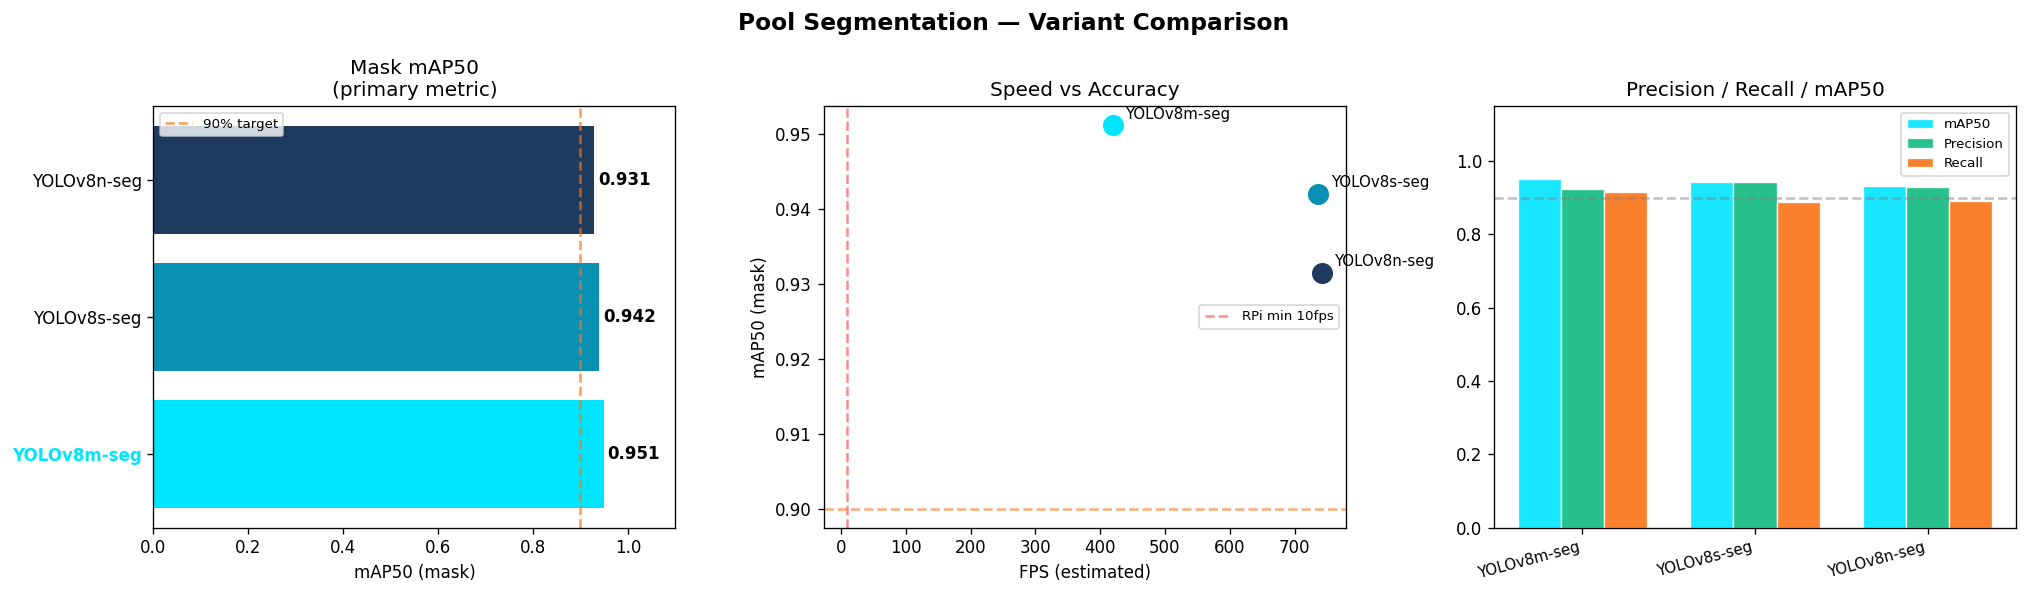

✓ Saved → comparison/variant_comparison.png


In [20]:
# 5.2 Comparison plots — 3 charts
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Pool Segmentation — Variant Comparison', fontsize=14, fontweight='bold')

colors = ['#00E5FF', '#0891B2', '#1E3A5F']
variants = df['Variant'].tolist()

# Chart 1: mAP50 (mask)
bars = axes[0].barh(variants, df['mAP50 (mask)'],
                    color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('mAP50 (mask)')
axes[0].set_xlim(0, 1.1)
axes[0].set_title('Mask mAP50\n(primary metric)')
axes[0].axvline(0.90, color='#F97316', linestyle='--', alpha=0.7, label='90% target')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, df['mAP50 (mask)']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
# Highlight best
axes[0].get_yticklabels()[0].set_color('#00E5FF')
axes[0].get_yticklabels()[0].set_fontweight('bold')

# Chart 2: Speed vs Accuracy
for i, row in df.iterrows():
    idx = list(df.index).index(i)
    axes[1].scatter(row['FPS'], row['mAP50 (mask)'],
                    s=200, c=colors[idx], edgecolors='white',
                    linewidth=1.5, zorder=5)
    axes[1].annotate(row['Variant'],
                     (row['FPS'], row['mAP50 (mask)']),
                     textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set_xlabel('FPS (estimated)')
axes[1].set_ylabel('mAP50 (mask)')
axes[1].set_title('Speed vs Accuracy')
axes[1].axvline(10, color='#EF4444', linestyle='--', alpha=0.6, label='RPi min 10fps')
axes[1].axhline(0.90, color='#F97316', linestyle='--', alpha=0.6)
axes[1].legend(fontsize=8)

# Chart 3: Precision / Recall / mAP50
x  = np.arange(len(df))
w  = 0.25
metric_colors = ['#00E5FF', '#10B981', '#F97316']
for i, (col, lbl) in enumerate([('mAP50 (mask)','mAP50'), ('Precision','Precision'), ('Recall','Recall')]):
    axes[2].bar(x + i*w, df[col], w, label=lbl,
                color=metric_colors[i], edgecolor='white', linewidth=0.8, alpha=0.9)
axes[2].set_xticks(x + w)
axes[2].set_xticklabels(df['Variant'], rotation=15, ha='right', fontsize=9)
axes[2].set_ylim(0, 1.15)
axes[2].set_title('Precision / Recall / mAP50')
axes[2].legend(fontsize=8)
axes[2].axhline(0.90, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(str(CMP_DIR / 'variant_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✓ Saved → comparison/variant_comparison.png')

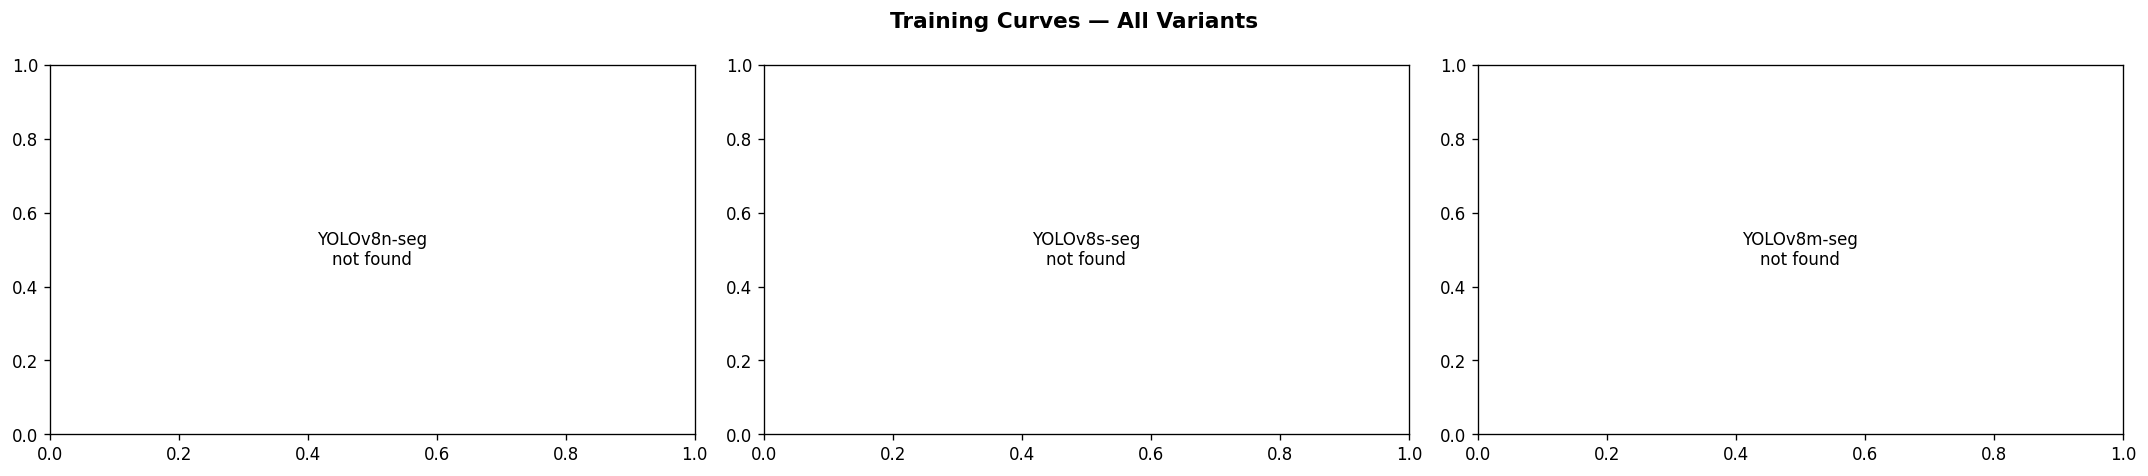

✓ Saved → comparison/training_curves.png


In [21]:
# 5.3 Training curves — load from YOLO results.csv
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Training Curves — All Variants', fontsize=13, fontweight='bold')

for ax, (tag, col) in zip(axes, [
    ('YOLOv8n-seg', '#00E5FF'),
    ('YOLOv8s-seg', '#0891B2'),
    ('YOLOv8m-seg', '#1E3A5F'),
]):
    csv_path = TRAIN_DIR / f'{tag.replace("-","_")}' / 'results.csv'
    if not csv_path.exists():
        ax.text(0.5, 0.5, f'{tag}\nnot found', ha='center',
                va='center', transform=ax.transAxes)
        continue
    df_t = pd.read_csv(csv_path)
    df_t.columns = df_t.columns.str.strip()

    # mAP50 and losses
    map_cols  = [c for c in df_t.columns if 'map50' in c.lower() and 'mask' in c.lower()]
    loss_cols = [c for c in df_t.columns if 'loss' in c.lower()][:2]

    ax2 = ax.twinx()
    for lc in loss_cols:
        ax.plot(df_t['epoch'], df_t[lc], alpha=0.6, linewidth=1.2,
                linestyle='--', label=lc.strip())
    for mc in map_cols:
        ax2.plot(df_t['epoch'], df_t[mc], color=col,
                 linewidth=2, label=mc.strip())

    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', fontsize=8)
    ax2.set_ylabel('mAP50', fontsize=8)
    ax.set_title(tag, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax2.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(str(CMP_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✓ Saved → comparison/training_curves.png')

In [22]:
# 5.4 Per-variant metrics saved individually
for tag, val in [('yolov8n_seg', val_n), ('yolov8s_seg', val_s), ('yolov8m_seg', val_m)]:
    variant_dir = TRAIN_DIR / tag
    variant_dir.mkdir(exist_ok=True)

    metrics = {
        'variant'        : tag,
        'mAP50_mask'     : round(float(val.seg.map50), 4),
        'mAP50_95_mask'  : round(float(val.seg.map),   4),
        'mAP50_box'      : round(float(val.box.map50), 4),
        'precision'      : round(float(val.seg.mp),    4),
        'recall'         : round(float(val.seg.mr),    4),
        'inference_ms'   : round(float(val.speed['inference']), 2),
        'fps'            : round(1000/float(val.speed['inference']), 1),
        'saved_at'       : datetime.now().isoformat(),
    }
    json.dump(metrics,
              open(str(variant_dir / 'metrics.json'), 'w'), indent=2)
    print(f'  ✓ {tag}/metrics.json')

print('\n✓ All variant metrics saved to Google Drive')

  ✓ yolov8n_seg/metrics.json
  ✓ yolov8s_seg/metrics.json
  ✓ yolov8m_seg/metrics.json

✓ All variant metrics saved to Google Drive


---
## 6 · Best Model Selection

> **Selection criterion:** Highest mask mAP50 at FPS > 10 on Raspberry Pi 5.
> Pool boundary accuracy matters most — a precise polygon mask reduces false alerts.


In [23]:
# 6.1 Select best variant
feasible = df[df['FPS'] > 10]
if feasible.empty:
    feasible = df  # fallback if all are slow

best = feasible.iloc[0]  # sorted by mAP50 descending

print('═' * 50)
print(f'  BEST MODEL: {best["Variant"]}')
print('═' * 50)
print(f'  mAP50 (mask):  {best["mAP50 (mask)"]}')
print(f'  mAP50-95:      {best["mAP50-95 (mask)"]}')
print(f'  Precision:     {best["Precision"]}')
print(f'  Recall:        {best["Recall"]}')
print(f'  FPS:           {best["FPS"]}')
print(f'  Weights:       {best["Weights"]}')
print('═' * 50)

══════════════════════════════════════════════════
  BEST MODEL: YOLOv8m-seg
══════════════════════════════════════════════════
  mAP50 (mask):  0.9512
  mAP50-95:      0.7758
  Precision:     0.9225
  Recall:        0.9152
  FPS:           419.7
  Weights:       /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/training/YOLOv8m_seg/weights/best.pt
══════════════════════════════════════════════════


In [24]:
# 6.2 Save best model info for Notebook 4 (Master)
best_info = {
    'model_num'        : 1,
    'best_variant'     : best['Variant'],
    'selection_reason' : 'Highest mask mAP50 at FPS > 10 — pool boundary accuracy is critical',
    'metrics'          : best.to_dict(),
    'selected_at'      : datetime.now().isoformat(),
}
best_json_path = SAVE_DIR / 'best_model.json'
json.dump(best_info, open(str(best_json_path), 'w'), indent=2)
print(f'✓ Saved → results/model1_pool_seg/best_model.json')
print(f'  Ready to use in Notebook 4 (Master Pipeline)')

✓ Saved → results/model1_pool_seg/best_model.json
  Ready to use in Notebook 4 (Master Pipeline)


Searching for saved weights...
  ✓ Found: /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/training/yolov8n_seg/weights/best.pt
  ✓ Found: /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/training/yolov8s_seg/weights/best.pt
  ✓ Found: /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/training/yolov8m_seg/weights/best.pt
✓ Using: YOLOv8m-seg  →  /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/training/yolov8m_seg/weights/best.pt

✓ Model loaded successfully
  Found 121 validation images


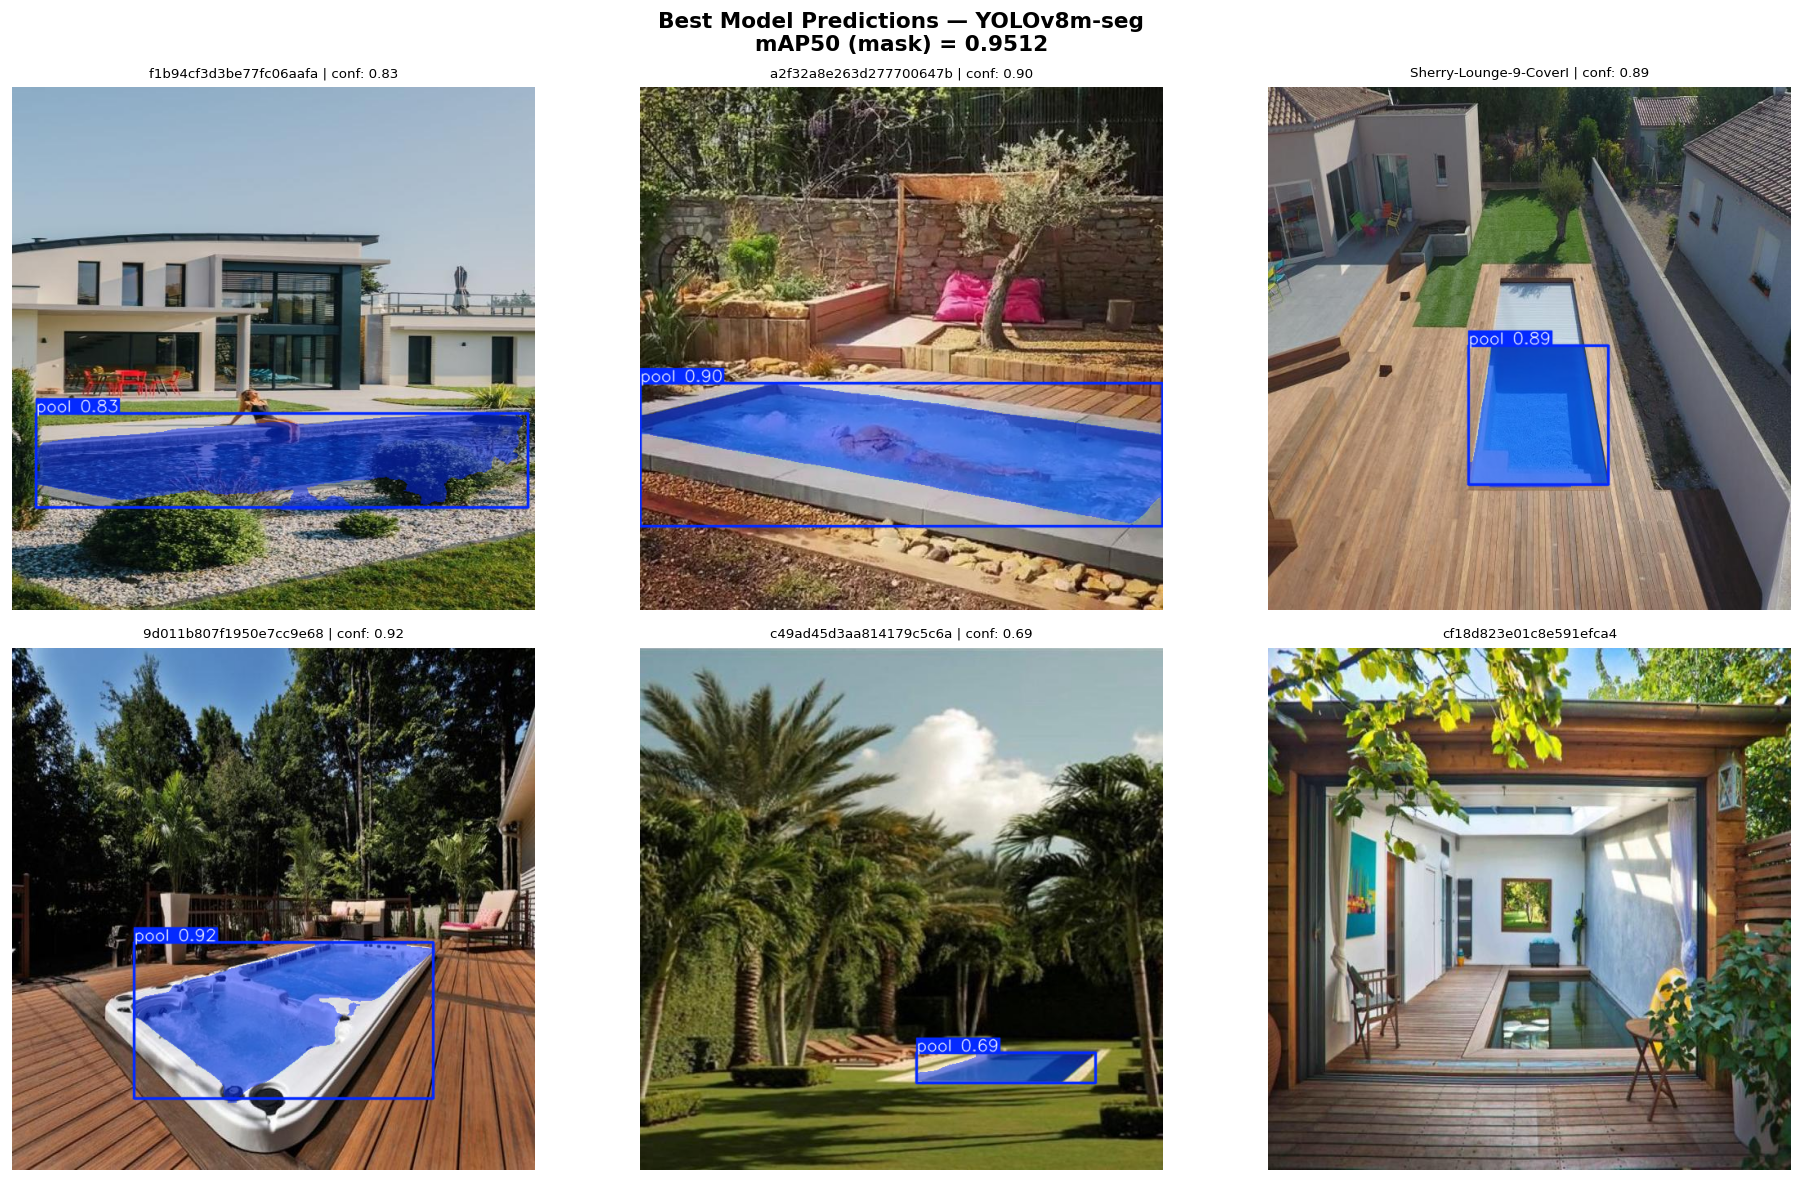

✓ Saved → /content/drive/MyDrive/AquaGuard_AI/results/model1_pool_seg/best_model_predictions.png


In [28]:
# 6.3 Test best model on validation images — corrected version

import glob

# ── Step 1: Find any saved weights on Drive ───────────────────────
print("Searching for saved weights...")
all_weights = glob.glob(str(TRAIN_DIR / '**' / 'best.pt'), recursive=True)

if not all_weights:
    print("✗ No weights found — re-run the training cells first")
else:
    for w in all_weights:
        print(f"  ✓ Found: {w}")

# ── Step 2: Pick best available weight ───────────────────────────
def get_best_weights(df, train_dir):
    """Try every variant name in df, return first weights file that exists."""
    for _, row in df.iterrows():
        # Try both lowercase-underscore and original name formats
        for folder in [
            row['Variant'].lower().replace('-', '_'),   # yolov8s_seg
            row['Variant'].replace('-', '_'),            # YOLOv8s_seg
            row['Variant'],                              # YOLOv8s-seg
        ]:
            w = Path(str(train_dir)) / folder / 'weights' / 'best.pt'
            if w.exists():
                print(f"✓ Using: {row['Variant']}  →  {w}")
                return str(w), row
    return None, None

weights_path, best_row = get_best_weights(df, TRAIN_DIR)

# Fallback: use any .pt file found anywhere
if weights_path is None and all_weights:
    weights_path = all_weights[0]
    best_row = df.iloc[0]
    print(f"  Using fallback weights: {weights_path}")

if weights_path is None:
    print("✗ Cannot proceed — no weights found. Re-run Section 4 training cells.")
    raise FileNotFoundError("No model weights found. Run training cells first.")

# ── Step 3: Load model ────────────────────────────────────────────
best_model = YOLO(weights_path)
print(f"\n✓ Model loaded successfully")

# ── Step 4: Get validation images ────────────────────────────────
val_imgs  = list((DATA_ROOT / 'valid' / 'images').glob('*.jpg'))
val_imgs += list((DATA_ROOT / 'valid' / 'images').glob('*.png'))

if not val_imgs:
    # Try test folder as fallback
    val_imgs  = list((DATA_ROOT / 'test' / 'images').glob('*.jpg'))
    val_imgs += list((DATA_ROOT / 'test' / 'images').glob('*.png'))
    print(f"  Using test images ({len(val_imgs)} found)")
else:
    print(f"  Found {len(val_imgs)} validation images")

n_show  = min(6, len(val_imgs))
samples = random.sample(val_imgs, n_show)

# ── Step 5: Plot predictions ──────────────────────────────────────
variant_name = best_row['Variant'] if best_row is not None else 'Best Model'
mAP_val      = best_row['mAP50 (mask)'] if best_row is not None else '—'

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f"Best Model Predictions — {variant_name}\n"
    f"mAP50 (mask) = {mAP_val}",
    fontsize=13, fontweight='bold'
)

for ax, img_path in zip(axes.flatten(), samples):
    results  = best_model(str(img_path), conf=0.5, verbose=False)[0]
    img_out  = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_out)

    conf_str = ''
    if results.boxes is not None and len(results.boxes) > 0:
        conf_str = f' | conf: {float(results.boxes.conf[0]):.2f}'

    ax.set_title(Path(img_path).name[:22] + conf_str, fontsize=8)
    ax.axis('off')

# Hide unused axes if fewer than 6 images
for ax in axes.flatten()[n_show:]:
    ax.axis('off')

plt.tight_layout()
save_path = str(SAVE_DIR / 'best_model_predictions.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {save_path}')

In [ ]:
# 6.4 Summary of all saved outputs
print('\n' + '═'*55)
print('  NOTEBOOK 1 COMPLETE — FILES SAVED TO GOOGLE DRIVE')
print('═'*55)
all_files = list(SAVE_DIR.rglob('*'))
for f in sorted(all_files):
    if f.is_file() and not f.name.startswith('.'):
        rel = f.relative_to(SAVE_DIR)
        print(f'  {rel}')
print('═'*55)
print(f'\n→ Proceed to Notebook 2: Child/Adult/Elderly Detection')